In [1]:
using Revise
using MajoranaPropagation
using PauliPropagation

using Plots 

In this notebook we discuss two topics: in the first part we address how different truncation settings can affect the results when using `FermionicGate`.

### To truncate or not to truncate?
Almost all fermionic operators that are commonly used require at least a couple of Majorana strings to be written down. When it comes to fermionic gates we hence often have the situation that multiple `MajoranaRotation`s are needed to implement a certain fermionic gate.

When applying a fermionic gate, the question is then when to truncate the Majorana sum: should we truncate after each Majorana rotation? Or only after we implemented the full fermionic gate?

To motivate why this can be relevant, let us look at the simple case of applying a hopping gate to a sum of local density operators and truncating after each rotation:

In [2]:
n_sites = 2 
gate = FermionicGate(:hop, [1, 2])
o1 = MajoranaSum(n_sites, :n, 1)
add!(o1, :n, 2)
propagate!([gate], o1, [0.1]; min_abs_coeff=1.e-10, truncate_each_mr=true)

#define again the same observable 
o2 = MajoranaSum(n_sites, :n, 1)
add!(o2, :n, 2)
propagate!([gate], o2, [0.1]; min_abs_coeff=0.1, truncate_each_mr=true)

@show o1 
@show o2;

o1 = MajoranaSum with 3 terms:
    1.0 * 00000000
    0.5 * 00110000
    0.5 * 11000000
o2 = MajoranaSum with 3 terms:
    1.0 * 00000000
    0.49501664446031046 * 00110000
    0.49501664446031046 * 11000000


If we truncate after each Majorana rotation with a coefficient trucation that is large enough (in this case, larger than $\sin(0.1)\approx 0.09983 $), we can induce a violation of number conservation even if the gate we applied (a hopping gate) is a number conserving gate. This comes from the fact that a hopping operator is decomposed as 
$$ f_i^{\dagger} f_j+f_j^{\dagger} f_i =\frac{1}{2} (i \gamma_i \gamma_j^{\prime}-i \gamma_i^{\prime} \gamma_j)$$
and so each Majorana string take by itself does not commute with density operators
$$ n_i=\frac{1}{2}(1+i \gamma_i \gamma_i^{\prime}) $$
but taken together they do.

In order to avoid this, the current default option in the code is to truncate after the fermionic gate for gates that are potentially non-number conserving even if they should (like hopping terms), and to truncate after each Majorana rotation if the individual Majorana strings are number preserving (like repulsion terms).

This default behaviour can be overwritten by the user with the `truncate_each_mr::Bool` key: setting it to `true` truncates after each Majorana rotation, `false` truncates after each fermionic gate.

Let's expolore how the expectation value of the spinless operator $O = n_4n_8$ is affected by the 3 truncation schemes (defalut, `truncate_each_mr=true` and `truncate_each_mr=false`) when we evolve it with the dynamics generated by $U(t)=\exp(-i t H)$ for
$$ H = h\sum_{\langle i,j\rangle} f_i^\dagger f_j +f_j^\dagger f_i + J \sum_{\langle i,j\rangle} n_i n_j$$

In [3]:
n_sites = 20 
topo = bricklayertopology(n_sites; periodic=true)

obs = MajoranaSum(n_sites, :nn, [4, 8])

gates = []
thetas = []
dt = 0.05
h = 1.
J = 0.5

for pair in topo 
    push!(gates, FermionicGate(:hop, pair))
    push!(thetas, 0.1)
end

for pair in topo 
    push!(gates, FermionicGate(:nn, pair))
    push!(thetas, 0.05)
end

In [4]:
initial_state = FockState(n_sites, 1:2:n_sites)

Fock state with 10 fermions at positions: 1, 3, 5, 7, 9, 11, 13, 15, 17, 19

In [5]:
min_abs_coeff = 1.e-4

n_layers = 55 

obs_default = deepcopy(obs)
obs_true = deepcopy(obs)
obs_false = deepcopy(obs)

res_default = zeros(n_layers+1)
res_true = zeros(n_layers+1)
res_false = zeros(n_layers+1)

lengths_default = zeros(n_layers+1)
lengths_true = zeros(n_layers+1)
lengths_false = zeros(n_layers+1)

res_default[1] = overlapwithfock(obs_default, initial_state)
res_true[1] = overlapwithfock(obs_true, initial_state)
res_false[1] = overlapwithfock(obs_false, initial_state)
lengths_default[1] = length(obs_default)
lengths_true[1] = length(obs_true)
lengths_false[1] = length(obs_false)

total_time_default = 0.0
total_time_true = 0.0
total_time_false = 0.0


for j = 1:n_layers 
    print("$j ")
    time_default = @elapsed propagate!(gates, obs_default, thetas; min_abs_coeff=min_abs_coeff)
    # truncate after each Majorana rotation 
    time_true = @elapsed propagate!(gates, obs_true, thetas; min_abs_coeff=min_abs_coeff, truncate_each_mr=true)
    # truncate only after the full fermionic gate
    time_false = @elapsed propagate!(gates, obs_false, thetas; min_abs_coeff=min_abs_coeff, truncate_each_mr=false)

    res_default[j+1] = overlapwithfock(obs_default, initial_state)
    res_true[j+1] = overlapwithfock(obs_true, initial_state)
    res_false[j+1] = overlapwithfock(obs_false, initial_state)

    lengths_default[j+1] = length(obs_default)
    lengths_true[j+1] = length(obs_true)
    lengths_false[j+1] = length(obs_false)

    total_time_default += time_default
    total_time_true += time_true
    total_time_false += time_false
end
println()

println("Total time default: $total_time_default")
println("Total time true: $total_time_true")
println("Total time false: $total_time_false");

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 
Total time default: 12.990496879000002
Total time true: 12.445986459
Total time false: 13.702947913999997


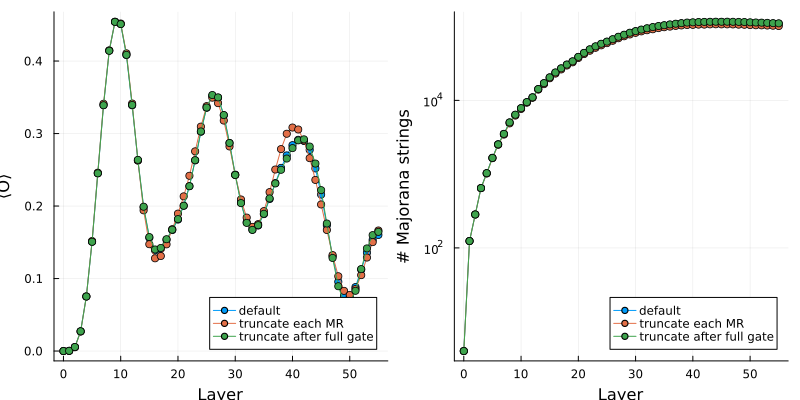

In [6]:
ev_plot = plot(xlabel="Layer", ylabel="⟨O⟩", legend=:bottomright)
plot!(ev_plot, 0:n_layers, res_default, label="default", marker=:circle)
plot!(ev_plot, 0:n_layers, res_true, label="truncate each MR", marker=:circle)
plot!(ev_plot, 0:n_layers, res_false, label="truncate after full gate", marker=:circle)

length_plot = plot(xlabel="Layer", ylabel="# Majorana strings", yscale=:log10, legend=:bottomright)
plot!(length_plot, 0:n_layers, lengths_default, label="default", marker=:circle)
plot!(length_plot, 0:n_layers, lengths_true, label="truncate each MR", marker=:circle)
plot!(length_plot, 0:n_layers, lengths_false, label="truncate after full gate", marker=:circle)

plot(ev_plot, length_plot, layout=(1,2), size=(800,400))

From the plot we see that the 3 methods all produce very similar number of strings, and that the default mode agrees with the `truncate_each_mr=false` truncation scheme more closely. The `truncate_each_mr=true` is the (slightly)faster method, at the expenses of some inaccuracies.

### Setting up custom fermionic gates
Now let's discuss how to define a custom symbol. For example we consider the particle-symmetric interaction term 
$$ U n_i n_j -\frac U2 n_i -\frac U2 n_j,$$
which is written, in terms of Majorana strings, as 
$$ \frac U2 1 - \frac U2 \gamma_i\gamma_i^\prime\gamma_j\gamma_j^\prime$$

In Majorana propagation, any custom symbol can be defined by writing the analogous of

In [7]:
function MajoranaPropagation.MajoranaSum(n_sites::Integer, ::Val{:nn_par_hol_symmetric}, sites)
    site1 = minimum(sites)
    site2 = maximum(sites)
    is_spinful = false
    obs = MajoranaSum(n_sites, [2*site1-1, 2*site1, 2*site2-1, 2*site2], is_spinful; coeff=-0.5)
    #get correct inttype
    TT = PauliPropagation.getinttype(nfermions(obs))
    add!(obs, TT(0), 0.5)
    return obs
end

Simply defining this even allows you to exponentiate it as a `FermionicGate`

In [8]:
n_sites = 15
topo = bricklayertopology(n_sites; periodic=true)

gates = []
thetas = []
dt = 0.05
h = 1.
J = 0.5

for pair in topo 
    push!(gates, FermionicGate(:hop, pair))
    push!(thetas, 0.1)
end

for pair in topo 
    push!(gates, FermionicGate(:nn_par_hol_symmetric, pair))
    push!(thetas, 0.05)
end

In [9]:
n_layers = 8 
min_abs_coeff = 1.e-5

obs = MajoranaSum(n_sites, :hop, [1, 4])

for _=1:n_layers
    propagate!(gates, obs, thetas; min_abs_coeff=min_abs_coeff)
    @show length(obs)
end


length(obs) = 610
length(obs) = 1646
length(obs) = 3500
length(obs) = 6733
length(obs) = 11863
length(obs) = 20526
length(obs) = 33758
length(obs) = 52955


By default this newly defined fermionic symbol will be trucated after each Majorana rotation:

In [10]:
MajoranaPropagation.flag_non_number_preserving(:nn_par_hol_symmetric)

false

but this behaviour can be overwritten

In [11]:
function MajoranaPropagation.flag_non_number_preserving(::Val{:nn_par_hol_symmetric})
    return true
end

MajoranaPropagation.flag_non_number_preserving(:nn_par_hol_symmetric)

true